In [1]:
import sys, pathlib
import os
import numpy as np


project_root = pathlib.Path.cwd().parent  # parent of notebooks/
sys.path.append(str(project_root))


from utils.plotting import (
    plot_runs_all_subjects,
    plot_session_averages_all_subjects,
    collect_rows,
)

from utils.metrics import (
    compute_all_metrics,
    load_subject,
)



Plotting functions defined.


In [2]:
# Root folder — one sub-directory per subject, e.g. data/NF/002GNV/
DATA_ROOT = "../../../Data/"

YEO_NAMES = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default",
]

def discover_subjects(data_root):
    """Return sorted list of subject IDs (= sub-folder names) in data_root."""
    return sorted(
        d for d in os.listdir(data_root)
        if os.path.isdir(os.path.join(data_root, d))
    )

# --- Discover and load all subjects ---
subject_ids = discover_subjects("../../../Data/")
print(f"Subjects found: {subject_ids}\n")

Subjects found: ['003GNV', '004GNV', '005GNV', '008GNV', '012GNV', '013GNV', '016GNV', '020GNV', '021GNV', '023GNV', '025GNV', '026GNV', '034GNV', '037GNV', '041GNV', '043GNV', '048GNV', '049GNV', '054GNV', '056GNV']



## 13. The Run 7 Dilemma

Three-way comparison of the dataset with:
1. Run 7 excluded (6 runs)
2. Run 7 included, no correction
3. Run 7 included with mixed-effects correction for the Run 7 offset

A per-subject correction variant is also provided.

In [3]:
# Reload the raw data into a fresh structure so this section is independent
# of any earlier filtering / removal of Run7.

import copy

all_data_run7raw = {}
for sid in subject_ids:
    sessions, yeo_labels = load_subject(DATA_ROOT, sid)
    all_data_run7raw[sid] = {"sessions": sessions, "yeo_labels": yeo_labels}

for sid, subj_data in all_data_run7raw.items():
    sessions = subj_data["sessions"]
    
    if "V03" in sessions and "Run8" in sessions["V03"]:
        del sessions["V03"]["Run8"]

compute_all_metrics(all_data_run7raw)

# Copy raw 7-run data before writing corrected values back in
all_data_run7corr = copy.deepcopy(all_data_run7raw)

print(f"Reloaded {len(all_data_run7raw)} subject(s) with Run7 included and recomputed metrics.")

  003GNV: 15 session file(s)
  004GNV: 15 session file(s)
  005GNV: 15 session file(s)
  008GNV: 15 session file(s)
  012GNV: 15 session file(s)
  013GNV: 15 session file(s)
  016GNV: 15 session file(s)
  020GNV: 15 session file(s)
  021GNV: 15 session file(s)
  023GNV: 15 session file(s)
  025GNV: 15 session file(s)
  026GNV: 15 session file(s)
  034GNV: 15 session file(s)
  037GNV: 15 session file(s)
  041GNV: 15 session file(s)
  043GNV: 15 session file(s)
  048GNV: 15 session file(s)
  049GNV: 15 session file(s)
  054GNV: 15 session file(s)
  056GNV: 15 session file(s)
Reloaded 20 subject(s) with Run7 included and recomputed metrics.


In [4]:
import pandas as pd
import statsmodels.formula.api as smf
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

# Flatten to a dataframe for mixed-effects correction
rows_dict = collect_rows(all_data_run7corr)
rows = [r for sub_rows in rows_dict.values() for r in sub_rows]
df_run7 = pd.DataFrame(rows)

df_run7["is_run7"] = (df_run7["run"] == "Run7").astype(int)

for i, _ in enumerate(YEO_NAMES):
    df_run7[f"seg_{i}"] = df_run7["segregation"].apply(lambda x: x[i])
    df_run7[f"int_{i}"] = df_run7["integration"].apply(lambda x: x[i])

print("Rows in df_run7:", len(df_run7))
df_run7[["subject", "session", "run", "condition", "is_run7"]].head()

Rows in df_run7: 1886


,subject,session,run,condition,is_run7
0,003GNV,V01,Run1,Feedback,0
1,003GNV,V01,Run2,Feedback,0
2,003GNV,V01,Run3,Feedback,0
3,003GNV,V01,Run4,Feedback,0
4,003GNV,V01,Run5,Feedback,0


In [5]:
# Correct segregation and integration separately, then recompute normalized segregation

seg_corr_cols = []
int_corr_cols = []
run7_effects = []

for i, net_name in enumerate(YEO_NAMES):
    seg_col = f"seg_{i}"
    int_col = f"int_{i}"

    seg_model = smf.mixedlm(
        f"{seg_col} ~ is_run7 + C(session)",
        data=df_run7,
        groups=df_run7["subject"]
    )
    seg_res = seg_model.fit()

    int_model = smf.mixedlm(
        f"{int_col} ~ is_run7 + C(session)",
        data=df_run7,
        groups=df_run7["subject"]
    )
    int_res = int_model.fit()

    beta_seg = seg_res.params.get("is_run7", 0.0)
    beta_int = int_res.params.get("is_run7", 0.0)

    df_run7[f"{seg_col}_corr"] = df_run7[seg_col] - beta_seg * df_run7["is_run7"]
    df_run7[f"{int_col}_corr"] = df_run7[int_col] - beta_int * df_run7["is_run7"]

    seg_corr_cols.append(f"{seg_col}_corr")
    int_corr_cols.append(f"{int_col}_corr")

    run7_effects.append({
        "network": net_name,
        "beta_run7_seg": beta_seg,
        "beta_run7_int": beta_int,
    })

effects_df = pd.DataFrame(run7_effects)
effects_df

,network,beta_run7_seg,beta_run7_int
0,Visual,0.006544,0.010153
1,Somatomotor,0.014928,0.017225
2,Dorsal Attention,0.005421,0.010859
3,Ventral Attention,0.006543,0.013543
4,Limbic,0.003810,0.012924
5,Frontoparietal,0.001266,0.007776
6,Default,0.010765,0.013622


In [6]:
# Rebuild corrected arrays and recompute normalized segregation from corrected seg/int

df_run7["segregation_corr"] = df_run7[seg_corr_cols].apply(lambda r: np.array(r.values, dtype=float), axis=1)
df_run7["integration_corr"] = df_run7[int_corr_cols].apply(lambda r: np.array(r.values, dtype=float), axis=1)
df_run7["normalized_segregation_corr"] = df_run7.apply(
    lambda r: (r["segregation_corr"] - r["integration_corr"]) / (r["segregation_corr"] + r["integration_corr"]),
    axis=1
)

for _, r in df_run7.iterrows():
    rd = all_data_run7corr[r["subject"]]["sessions"][r["session"]][r["run"]]
    rd["segregation"] = r["segregation_corr"]
    rd["integration"] = r["integration_corr"]
    rd["normalized_segregation"] = r["normalized_segregation_corr"]

print("Run7 correction written back into all_data_run7corr.")

Run7 correction written back into all_data_run7corr.


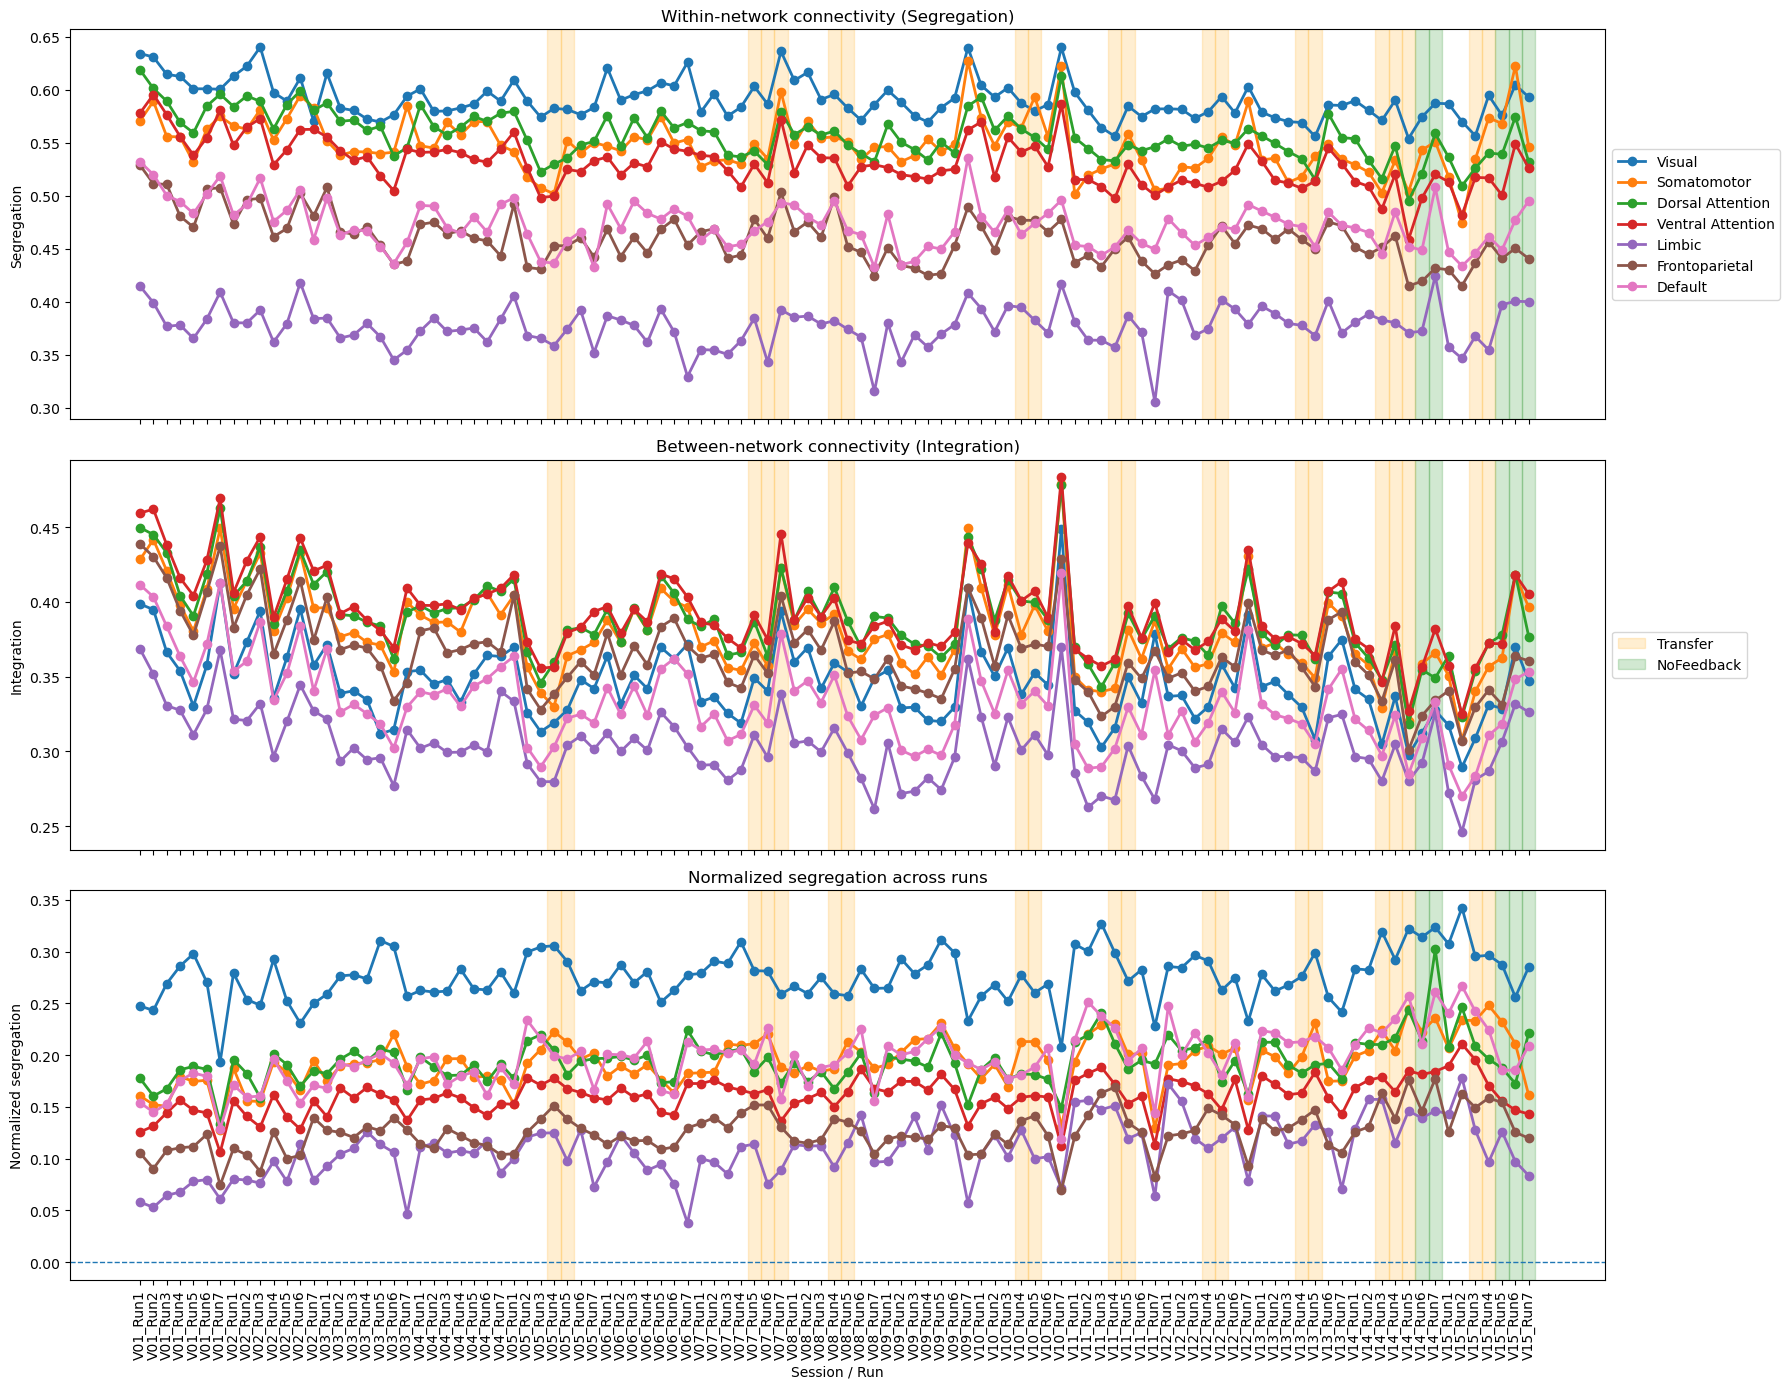

In [7]:
# Raw 7-run plot without correction
plot_runs_all_subjects(
    all_data_run7raw,
    YEO_NAMES,
    average_only=True,
    shade_conditions=True,
    show_subject_counts=False
)

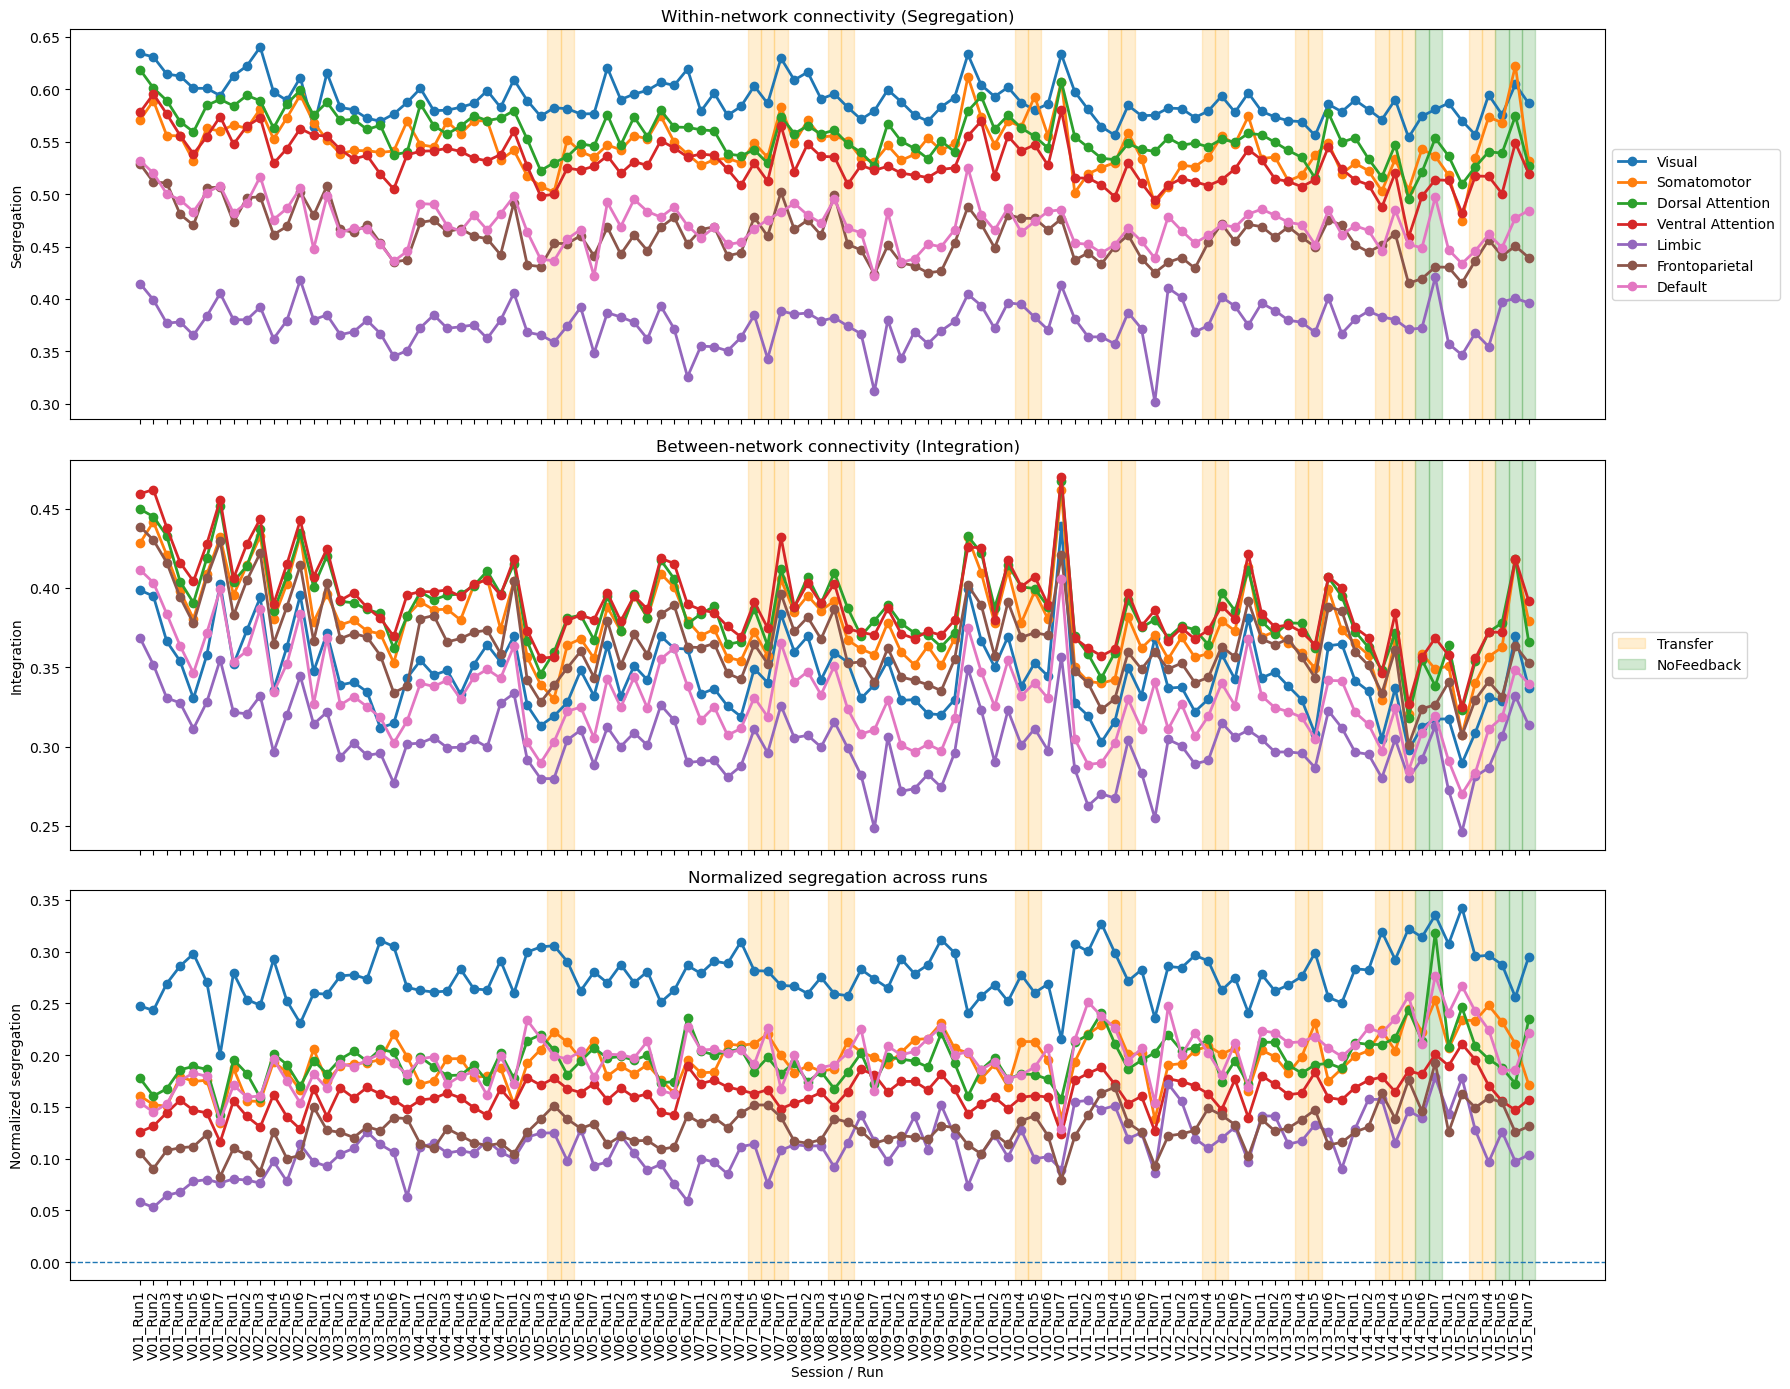

In [8]:
# Corrected 7-run plot
plot_runs_all_subjects(
    all_data_run7corr,
    YEO_NAMES,
    average_only=True,
    shade_conditions=True,
    show_subject_counts=False
)

### 13b. √n-normalisation correction

Divide each group-average metric value by **√n** (number of subjects contributing
to that run point). No model fitting — run points with fewer subjects are simply
down-weighted by the standard-error scaling factor.

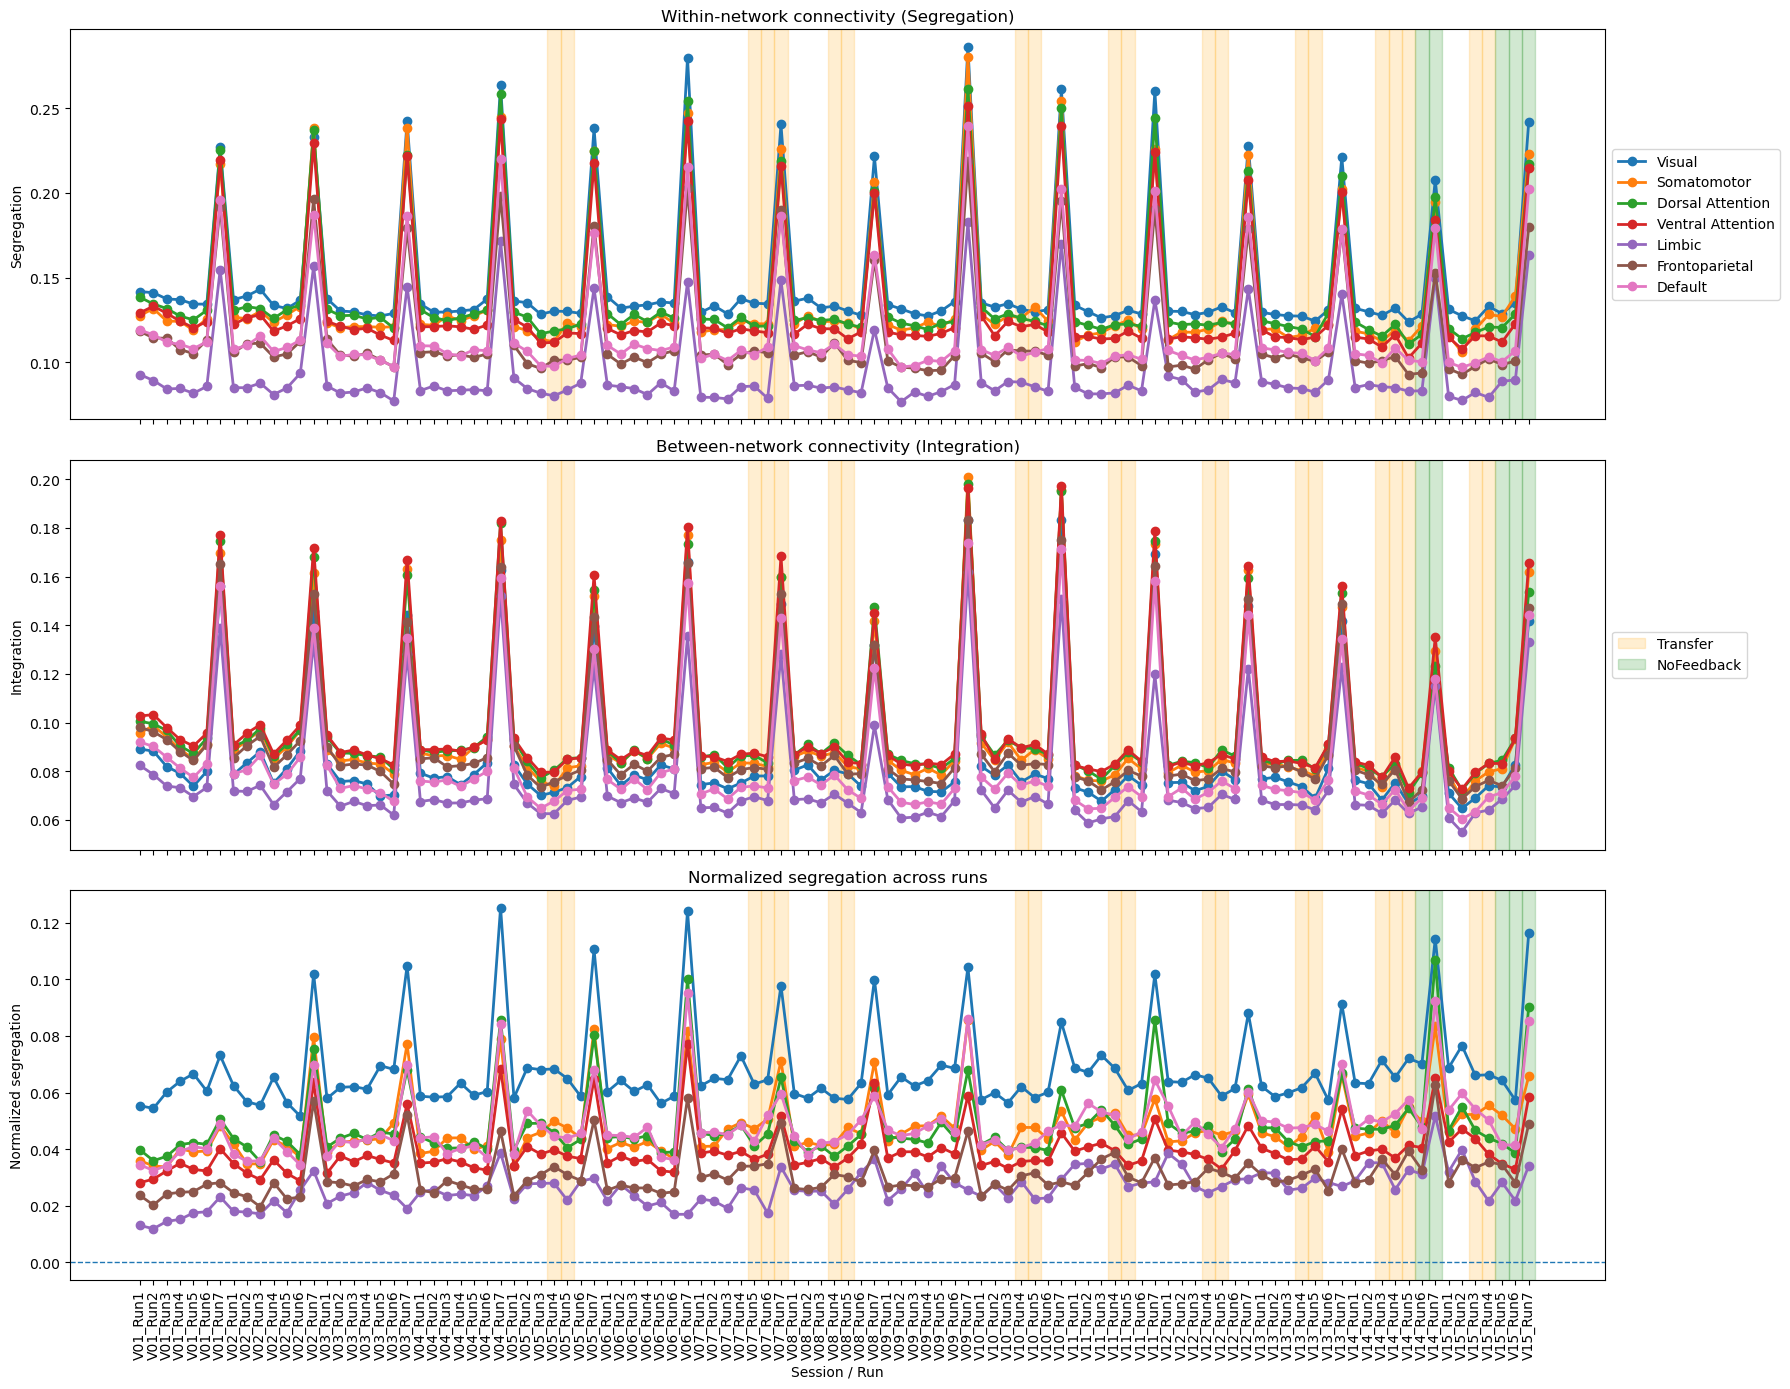

In [9]:
def correct_run7_sqrtn(all_data):
    """
    Return a deep copy of all_data where every run's metrics are divided
    by sqrt(n_subjects_with_that_run).

    'n' for a given Session_Run is the number of subjects that actually have
    data for that run (same value used for the group-average in the plots).
    """
    import copy

    # Count subjects per (session, run) key
    run_counts = {}
    for sid, subj in all_data.items():
        for sess_id, sess_runs in subj["sessions"].items():
            for run_key in sess_runs:
                k = (sess_id, run_key)
                run_counts[k] = run_counts.get(k, 0) + 1

    all_data_corr = copy.deepcopy(all_data)
    for sid, subj in all_data_corr.items():
        for sess_id, sess_runs in subj["sessions"].items():
            for run_key, rd in sess_runs.items():
                n = run_counts[(sess_id, run_key)]
                s = np.sqrt(n)
                rd["segregation"]           = rd["segregation"]           / s
                rd["integration"]           = rd["integration"]           / s
                rd["normalized_segregation"] = rd["normalized_segregation"] / s
    return all_data_corr


all_data_run7sqrtn = correct_run7_sqrtn(all_data_run7raw)

plot_runs_all_subjects(
    all_data_run7sqrtn,
    YEO_NAMES,
    average_only=True,
    shade_conditions=True,
    show_subject_counts=False
)